# Tổng hợp các phương pháp huấn luyện và lưu checkpoint để đánh giá tùng phương pháp

## Môi trường các game

In [1]:
from utils.coin_simple_env import coin_game
from utils.ttt_simple_env import ttt
from utils.conn_simple_env import conn

GAME_ENVS = {
    "coin": coin_game,
    "ttt": ttt,
    "conn": conn,
}


def make_env(game):
    return GAME_ENVS[game]()

## Coin game

### Áp dụng rule-based AI

In [2]:
def coin_rule_agent(env):
    if env.state % 3 != 0:
        move = env.state % 3
    else:
        move = env.sample()
    return move

### Neural Network

In [3]:
import os
import pickle
import random
import numpy as np
from tqdm.auto import tqdm
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from utils.coin_simple_env import coin_game

os.makedirs("files/checkpoints", exist_ok=True)


def expert(env):
    if env.state % 3 != 0:
        move = env.state % 3
    else:
        move = random.choice([1, 2])
    return move


def non_expert(env):
    if env.state % 3 != 0 and np.random.rand() < 0.5:
        move = env.state % 3
    else:
        move = random.choice([1, 2])
    return move


def one_game(episode):
    env = coin_game()
    history = []
    state = env.reset()
    if episode % 2 == 0:
        action = non_expert(env)
        state, reward, done, _ = env.step(action)
    while True:
        action = expert(env)
        history.append((state, action))
        state, reward, done, _ = env.step(action)
        if done:
            break
        action = non_expert(env)
        state, reward, done, _ = env.step(action)
        if done:
            break
    return history


results = []
for episode in tqdm(range(10000), desc="Tạo dữ liệu coin", unit="ván"):
    results.extend(one_game(episode))
    if (episode + 1) % 1000 == 0:
        with open("files/checkpoints/games_coin_checkpoint.p", "wb") as fp:
            pickle.dump(results, fp)

with open("files/games_coin.p", "wb") as fp:
    pickle.dump(results, fp)

states = []
actions = []
for state, action in results:
    states.append(to_categorical(state, 22))
    actions.append(to_categorical(action - 1, 2))

X = np.asarray(states).reshape((-1, 22))
y = np.asarray(actions).reshape((-1, 2))

fast_model = Sequential([
    Dense(32, activation="relu", input_shape=(22,)),
    Dense(2, activation="softmax"),
])
fast_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

strong_model = Sequential([
    Dense(64, activation="relu", input_shape=(22,)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(2, activation="softmax"),
])
strong_model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

fast_model.fit(
    X, y, epochs=25, verbose=1,
    callbacks=[ModelCheckpoint(
        "files/checkpoints/fast_coin_epoch_{epoch:02d}.h5",
        save_freq="epoch",
    )],
)
strong_model.fit(
    X, y, epochs=25, verbose=1,
    callbacks=[ModelCheckpoint(
        "files/checkpoints/strong_coin_epoch_{epoch:02d}.h5",
        save_freq="epoch",
    )],
)

fast_model.save("files/fast_coin.h5")
strong_model.save("files/strong_coin.h5")
print("Đã tạo dữ liệu, hiển thị tiến độ và lưu checkpoint theo epoch")

C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Tạo dữ liệu coin: 100%|██████████| 10000/10000 [00:00<00:00, 41939.01ván/s]


Epoch 1/25
2255/2255 [==============================] - 3s 923us/step - loss: 0.2106 - accuracy: 0.8710
Epoch 2/25
2255/2255 [==============================] - 2s 1ms/step - loss: 0.1685 - accuracy: 0.8803
Epoch 3/25
2255/2255 [==============================] - 2s 924us/step - loss: 0.1684 - accuracy: 0.8789
Epoch 4/25
2255/2255 [==============================] - 2s 981us/step - loss: 0.1682 - accuracy: 0.8801
Epoch 5/25
2255/2255 [==============================] - 3s 1ms/step - loss: 0.1682 - accuracy: 0.8778
Epoch 6/25
2255/2255 [==============================] - 3s 1ms/step - loss: 0.1680 - accuracy: 0.8803
Epoch 7/25
2255/2255 [==============================] - 2s 1ms/step - loss: 0.1681 - accuracy: 0.8788
Epoch 8/25
2255/2255 [==============================] - 3s 1ms/step - loss: 0.1681 - accuracy: 0.8776
Epoch 9/25
2255/2255 [==============================] - 4s 2ms/step - loss: 0.1682 - accuracy: 0.8790
Epoch 10/25
2255/2255 [==============================] - 3s 1ms/step - loss:

In [4]:
from tensorflow.keras.models import load_model
from utils.coin_simple_env import coin_game


def checkpoint_move(model, env):
    state = np.zeros((1, 22))
    state[0, env.state] = 1
    probabilities = model.predict(state, verbose=0)[0]
    valid_moves = sorted(env.validinputs)
    valid_probabilities = probabilities[np.asarray(valid_moves) - 1]
    valid_probabilities = valid_probabilities / valid_probabilities.sum()
    return int(np.random.choice(valid_moves, p=valid_probabilities))


def random_move(env):
    return env.sample()


def play_checkpoint(model, checkpoint_name, checkpoint_first=True, games=100, show_game=True):
    wins = 0
    losses = 0
    draws = 0
    sample_moves = []

    for game_number in range(games):
        env = coin_game()
        env.reset()
        moves = []

        while not env.done:
            if checkpoint_first:
                action = checkpoint_move(model, env)
                player = "checkpoint"
            else:
                action = random_move(env)
                player = "random"
            env.step(action)
            moves.append((player, action, env.state))
            if env.done:
                break

            if checkpoint_first:
                action = random_move(env)
                player = "random"
            else:
                action = checkpoint_move(model, env)
                player = "checkpoint"
            env.step(action)
            moves.append((player, action, env.state))

        checkpoint_reward = env.reward if checkpoint_first else -env.reward
        if checkpoint_reward == 1:
            wins += 1
        elif checkpoint_reward == -1:
            losses += 1
        else:
            draws += 1

        if game_number == 0:
            sample_moves = moves

    if show_game:
        print(f"\n{checkpoint_name} | checkpoint_first={checkpoint_first}")
        print("Các nước của ván mẫu:")
        for player, action, state in sample_moves:
            print(f"{player}: lấy {action} coin, còn {state}")

    print(f"{checkpoint_name} | thắng: {wins}, thua: {losses}, hòa: {draws}")
    return {"checkpoint": checkpoint_name, "first": checkpoint_first,
            "wins": wins, "losses": losses, "draws": draws,
            "win_rate": wins / games}


fast_checkpoint = load_model("files/fast_coin.h5")
strong_checkpoint = load_model("files/strong_coin.h5")

checkpoint_results = []
for name, model in [("fast_coin", fast_checkpoint), ("strong_coin", strong_checkpoint)]:
    checkpoint_results.append(play_checkpoint(model, name, checkpoint_first=True))
    checkpoint_results.append(play_checkpoint(model, name, checkpoint_first=False))

checkpoint_results


fast_coin | checkpoint_first=True
Các nước của ván mẫu:
checkpoint: lấy 1 coin, còn 20
random: lấy 1 coin, còn 19
checkpoint: lấy 1 coin, còn 18
random: lấy 2 coin, còn 16
checkpoint: lấy 1 coin, còn 15
random: lấy 2 coin, còn 13
checkpoint: lấy 1 coin, còn 12
random: lấy 2 coin, còn 10
checkpoint: lấy 1 coin, còn 9
random: lấy 2 coin, còn 7
checkpoint: lấy 1 coin, còn 6
random: lấy 1 coin, còn 5
checkpoint: lấy 2 coin, còn 3
random: lấy 1 coin, còn 2
checkpoint: lấy 2 coin, còn 0
fast_coin | thắng: 100, thua: 0, hòa: 0

fast_coin | checkpoint_first=False
Các nước của ván mẫu:
random: lấy 2 coin, còn 19
checkpoint: lấy 1 coin, còn 18
random: lấy 2 coin, còn 16
checkpoint: lấy 1 coin, còn 15
random: lấy 2 coin, còn 13
checkpoint: lấy 1 coin, còn 12
random: lấy 2 coin, còn 10
checkpoint: lấy 1 coin, còn 9
random: lấy 1 coin, còn 8
checkpoint: lấy 2 coin, còn 6
random: lấy 1 coin, còn 5
checkpoint: lấy 2 coin, còn 3
random: lấy 2 coin, còn 1
checkpoint: lấy 1 coin, còn 0
fast_coin | thắn

[{'checkpoint': 'fast_coin',
  'first': True,
  'wins': 100,
  'losses': 0,
  'draws': 0,
  'win_rate': 1.0},
 {'checkpoint': 'fast_coin',
  'first': False,
  'wins': 100,
  'losses': 0,
  'draws': 0,
  'win_rate': 1.0},
 {'checkpoint': 'strong_coin',
  'first': True,
  'wins': 100,
  'losses': 0,
  'draws': 0,
  'win_rate': 1.0},
 {'checkpoint': 'strong_coin',
  'first': False,
  'wins': 100,
  'losses': 0,
  'draws': 0,
  'win_rate': 1.0}]

### MCTS

In [5]:
import pickle
from tqdm.auto import tqdm
from utils.coin_simple_env import coin_game
from utils.ch08util import naive_mcts

os.makedirs("files/checkpoints", exist_ok=True)
naive_mcts_results = []
for game_number in tqdm(range(100), desc="Naive MCTS", unit="ván"):
    env = coin_game()
    state = env.reset()

    if game_number % 2 == 0:
        action = env.sample()
        state, reward, done, info = env.step(action)

    while True:
        action = naive_mcts(env, num_rollouts=1000)
        state, reward, done, info = env.step(action)
        if done:
            naive_mcts_results.append(1)
            break

        action = env.sample()
        state, reward, done, info = env.step(action)
        if done:
            naive_mcts_results.append(-1)
            break

    if (game_number + 1) % 10 == 0:
        with open("files/checkpoints/naive_mcts_coin_checkpoint.p", "wb") as fp:
            pickle.dump(naive_mcts_results, fp)

with open("files/checkpoints/naive_mcts_coin_results.p", "wb") as fp:
    pickle.dump(naive_mcts_results, fp)

naive_mcts_wins = naive_mcts_results.count(1)
naive_mcts_losses = naive_mcts_results.count(-1)
naive_mcts_draws = naive_mcts_results.count(0)
print(f"Naive MCTS wins: {naive_mcts_wins}")
print(f"Naive MCTS losses: {naive_mcts_losses}")
print(f"Naive MCTS draws: {naive_mcts_draws}")

Naive MCTS:   0%|          | 0/100 [00:00<?, ?ván/s]

Naive MCTS: 100%|██████████| 100/100 [00:27<00:00,  3.62ván/s]

Naive MCTS wins: 95
Naive MCTS losses: 5
Naive MCTS draws: 0


### MCTS + NN

In [6]:
import pickle
from tqdm.auto import tqdm
from utils.coin_simple_env import coin_game
from utils.ch08util import select, expand, backpropagate, next_move


def onehot_encoder_coin(state):
    onehot = np.zeros((1, 22))
    onehot[0, state] = 1
    return onehot


def policy_simulate_coin(env_copy, done, reward, model):
    if done:
        return reward
    while True:
        action_probs = model(onehot_encoder_coin(env_copy.state), training=False)
        action_probs = np.asarray(action_probs).reshape(-1)
        valid_moves = sorted(env_copy.validinputs)
        probabilities = action_probs[np.asarray(valid_moves) - 1]
        probabilities = probabilities / probabilities.sum()
        move = np.random.choice(valid_moves, p=probabilities)
        state, reward, done, info = env_copy.step(move)
        if done:
            return reward


def policy_mcts_coin(env, model, num_rollouts=100, temperature=1.4):
    if len(env.validinputs) == 1:
        return env.validinputs[0]
    counts = {move: 0 for move in env.validinputs}
    wins = {move: 0 for move in env.validinputs}
    losses = {move: 0 for move in env.validinputs}
    for _ in range(num_rollouts):
        move = select(env, counts, wins, losses, temperature)
        env_copy, done, reward = expand(env, move)
        reward = policy_simulate_coin(env_copy, done, reward, model)
        counts, wins, losses = backpropagate(
            env, move, reward, counts, wins, losses
        )
    return next_move(counts, wins, losses)


policy_mcts_results = []
for game_number in tqdm(range(100), desc="Policy-Based MCTS", unit="ván"):
    env = coin_game()
    state = env.reset()
    if game_number % 2 == 0:
        action = env.sample()
        state, reward, done, info = env.step(action)
    while True:
        action = policy_mcts_coin(env, fast_model, num_rollouts=100)
        state, reward, done, info = env.step(action)
        if done:
            policy_mcts_results.append(1)
            break
        action = env.sample()
        state, reward, done, info = env.step(action)
        if done:
            policy_mcts_results.append(-1)
            break
    if (game_number + 1) % 10 == 0:
        with open("files/checkpoints/policy_mcts_coin_checkpoint.p", "wb") as fp:
            pickle.dump(policy_mcts_results, fp)

with open("files/checkpoints/policy_mcts_coin_results.p", "wb") as fp:
    pickle.dump(policy_mcts_results, fp)

policy_mcts_wins = policy_mcts_results.count(1)
policy_mcts_losses = policy_mcts_results.count(-1)
policy_mcts_draws = policy_mcts_results.count(0)
print(f"Policy-Based MCTS wins: {policy_mcts_wins}")
print(f"Policy-Based MCTS losses: {policy_mcts_losses}")
print(f"Policy-Based MCTS draws: {policy_mcts_draws}")

Policy-Based MCTS: 100%|██████████| 100/100 [12:39<00:00,  7.59s/ván]

Policy-Based MCTS wins: 99
Policy-Based MCTS losses: 1
Policy-Based MCTS draws: 0


### AlphaGO Implement

In [7]:
import pickle
import random
from tqdm.auto import tqdm
from utils.coin_simple_env import coin_game
from utils.ch16util import alphago_coin

os.makedirs("files/checkpoints", exist_ok=True)
alphago_results = []
for game_number in tqdm(range(100), desc="AlphaGo", unit="ván"):
    env = coin_game()
    state = env.reset()
    if game_number % 2 == 0:
        action = random.choice(env.validinputs)
        state, reward, done, info = env.step(action)
    while True:
        action = alphago_coin(
            env, weight=0.9, depth=10, num_rollouts=100
        )
        state, reward, done, info = env.step(action)
        if done:
            alphago_results.append(1)
            break
        action = random.choice(env.validinputs)
        state, reward, done, info = env.step(action)
        if done:
            alphago_results.append(-1)
            break
    if (game_number + 1) % 10 == 0:
        with open("files/checkpoints/alphago_coin_checkpoint.p", "wb") as fp:
            pickle.dump(alphago_results, fp)

with open("files/checkpoints/alphago_coin_results.p", "wb") as fp:
    pickle.dump(alphago_results, fp)

alphago_wins = alphago_results.count(1)
alphago_losses = alphago_results.count(-1)
alphago_draws = alphago_results.count(0)
print(f"AlphaGo wins: {alphago_wins}")
print(f"AlphaGo losses: {alphago_losses}")
print(f"AlphaGo draws: {alphago_draws}")

AlphaGo: 100%|██████████| 100/100 [24:44<00:00, 14.85s/ván]

AlphaGo wins: 98
AlphaGo losses: 2
AlphaGo draws: 0


### Chơi với player random và xem kết quả

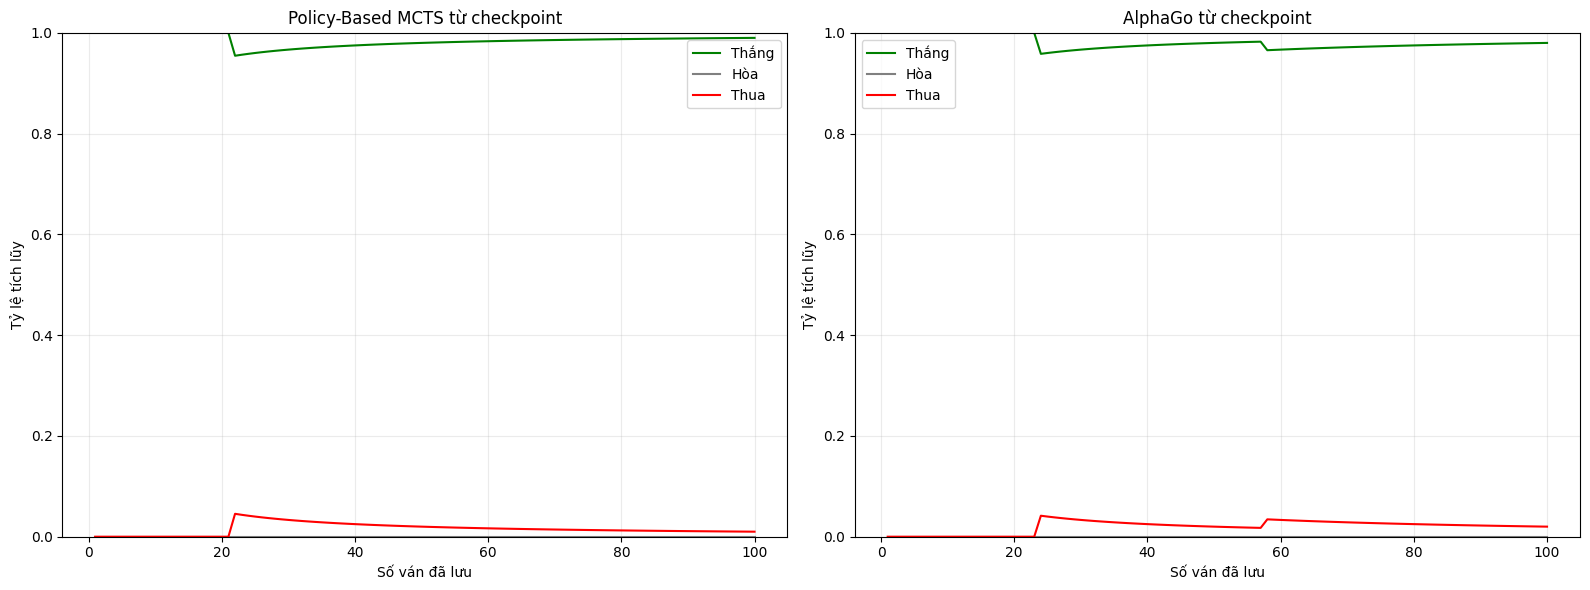

Đã load Policy-Based MCTS từ: files\checkpoints\policy_mcts_coin_results.p
Đã load AlphaGo từ: files\checkpoints\alphago_coin_results.p


,agent,games,wins,draws,losses,wins_rate,draws_rate,losses_rate
195,AlphaGo,96,94,0,2,0.979167,0.0,0.020833
196,AlphaGo,97,95,0,2,0.979381,0.0,0.020619
197,AlphaGo,98,96,0,2,0.979592,0.0,0.020408
198,AlphaGo,99,97,0,2,0.979798,0.0,0.020202
199,AlphaGo,100,98,0,2,0.980000,0.0,0.020000


In [10]:
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CHECKPOINT_DIR = Path("files/checkpoints")
RESULT_DIR = CHECKPOINT_DIR / "evaluation"
RESULT_DIR.mkdir(parents=True, exist_ok=True)


def load_saved_results(final_name, checkpoint_name):
    final_path = CHECKPOINT_DIR / final_name
    checkpoint_path = CHECKPOINT_DIR / checkpoint_name
    path = final_path if final_path.exists() else checkpoint_path
    with open(path, "rb") as fp:
        return pickle.load(fp), path


def cumulative_results(results, label):
    rows = []
    for game_number in range(1, len(results) + 1):
        completed = results[:game_number]
        rows.append({
            "agent": label,
            "games": game_number,
            "wins": completed.count(1),
            "draws": completed.count(0),
            "losses": completed.count(-1),
        })
    table = pd.DataFrame(rows)
    for column in ["wins", "draws", "losses"]:
        table[f"{column}_rate"] = table[column] / table["games"]
    return table


policy_results, policy_path = load_saved_results(
    "policy_mcts_coin_results.p",
    "policy_mcts_coin_checkpoint.p",
)
alphago_saved_results, alphago_path = load_saved_results(
    "alphago_coin_results.p",
    "alphago_coin_checkpoint.p",
)

policy_mcts_results = cumulative_results(policy_results, "Policy-Based MCTS")
alphago_results = cumulative_results(alphago_saved_results, "AlphaGo")
loaded_results = pd.concat([policy_mcts_results, alphago_results], ignore_index=True)
loaded_results.to_csv(RESULT_DIR / "loaded_mcts_alphago_results.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for table, axis, title in [
    (policy_mcts_results, axes[0], "Policy-Based MCTS từ checkpoint"),
    (alphago_results, axes[1], "AlphaGo từ checkpoint"),
]:
    axis.plot(table["games"], table["wins_rate"], label="Thắng", color="green")
    axis.plot(table["games"], table["draws_rate"], label="Hòa", color="gray")
    axis.plot(table["games"], table["losses_rate"], label="Thua", color="red")
    axis.set_title(title)
    axis.set_xlabel("Số ván đã lưu")
    axis.set_ylabel("Tỷ lệ tích lũy")
    axis.set_ylim(0, 1)
    axis.grid(alpha=0.25)
    axis.legend()

plt.tight_layout()
plt.savefig(RESULT_DIR / "loaded_mcts_alphago_results.png", dpi=150)
plt.show()

print(f"Đã load Policy-Based MCTS từ: {policy_path}")
print(f"Đã load AlphaGo từ: {alphago_path}")
loaded_results.tail()

## TicTacToe

### NN

In [20]:
import os
import pickle
from copy import deepcopy
import numpy as np
from tqdm.auto import tqdm
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Conv2D, Dense, Flatten
from tensorflow.keras.models import Sequential
from utils.ch06util import MiniMax_ab
from utils.ttt_simple_env import ttt

os.makedirs("files/checkpoints", exist_ok=True)


def expert_ttt(env):
    return MiniMax_ab(env)


def non_expert_ttt(env):
    if np.random.rand() < 0.5:
        return MiniMax_ab(env)
    return env.sample()


def one_ttt_game(episode):
    env = ttt()
    history = []
    state = env.reset()
    if episode % 2 == 0:
        action = non_expert_ttt(env)
        state, reward, done, _ = env.step(action)
    while True:
        action = expert_ttt(env)
        state_for_model = deepcopy(-state if episode % 2 == 0 else state)
        history.append((state_for_model, deepcopy(action)))
        state, reward, done, _ = env.step(action)
        if done:
            break
        action = non_expert_ttt(env)
        state, reward, done, _ = env.step(action)
        if done:
            break
    return history


results = []
for episode in tqdm(range(500), desc="Tạo dữ liệu TTT", unit="ván"):
    results.extend(one_ttt_game(episode))
    if (episode + 1) % 1000 == 0:
        with open("files/checkpoints/games_ttt_checkpoint.p", "wb") as fp:
            pickle.dump(results, fp)

with open("files/games_ttt.p", "wb") as fp:
    pickle.dump(results, fp)

X = np.asarray([state for state, action in results]).reshape((-1, 3, 3, 1))
y = np.asarray([action - 1 for state, action in results])

fast_ttt_model = Sequential([
    Conv2D(128, (3, 3), padding="same", activation="relu", input_shape=(3, 3, 1)),
    Flatten(), Dense(64, activation="relu"), Dense(64, activation="relu"),
    Dense(9, activation="softmax"),
])
fast_ttt_model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

strong_ttt_model = Sequential([
    Conv2D(128, (3, 3), padding="same", activation="relu", input_shape=(3, 3, 1)),
    Flatten(), Dense(64, activation="relu"), Dense(64, activation="relu"),
    Dense(64, activation="relu"), Dense(9, activation="softmax"),
])
strong_ttt_model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

fast_ttt_history = fast_ttt_model.fit(X, y, epochs=100, verbose=1, callbacks=[ModelCheckpoint(
    "files/checkpoints/fast_ttt_epoch_{epoch:03d}.h5", save_freq="epoch")])
strong_ttt_history = strong_ttt_model.fit(X, y, epochs=100, verbose=1, callbacks=[ModelCheckpoint(
    "files/checkpoints/strong_ttt_epoch_{epoch:03d}.h5", save_freq="epoch")])

fast_ttt_model.save("files/fast_ttt.h5")
strong_ttt_model.save("files/strong_ttt.h5")
print("Đã tạo dữ liệu và huấn luyện hai policy CNN Tic-Tac-Toe")

Tạo dữ liệu TTT:   0%|          | 0/500 [00:00<?, ?ván/s]

Tạo dữ liệu TTT: 100%|██████████| 500/500 [14:13<00:00,  1.71s/ván]

Epoch 1/100


60/60 [==============================] - 1s 5ms/step - loss: 2.1564 - accuracy: 0.1794
Epoch 2/100
60/60 [==============================] - 0s 5ms/step - loss: 1.9296 - accuracy: 0.3235
Epoch 3/100
60/60 [==============================] - 0s 4ms/step - loss: 1.6095 - accuracy: 0.4327
Epoch 4/100
60/60 [==============================] - 0s 6ms/step - loss: 1.4055 - accuracy: 0.5140
Epoch 5/100
60/60 [==============================] - 0s 3ms/step - loss: 1.2385 - accuracy: 0.5520
Epoch 6/100
60/60 [==============================] - 0s 4ms/step - loss: 1.1392 - accuracy: 0.5836
Epoch 7/100
60/60 [==============================] - 0s 4ms/step - loss: 1.0834 - accuracy: 0.5900
Epoch 8/100
60/60 [==============================] - 0s 4ms/step - loss: 1.0254 - accuracy: 0.6153
Epoch 9/100
60/60 [==============================] - 0s 6ms/step - loss: 0.9771 - accuracy: 0.6195
Epoch 10/100
60/60 [==============================] - 0s 6ms/step - loss: 0.9439 - accuracy: 0.6354
Epoch 11/100
60/60 [=

array([<Axes: xlabel='ván'>, <Axes: xlabel='ván'>, <Axes: xlabel='ván'>,
       <Axes: xlabel='ván'>], dtype=object)

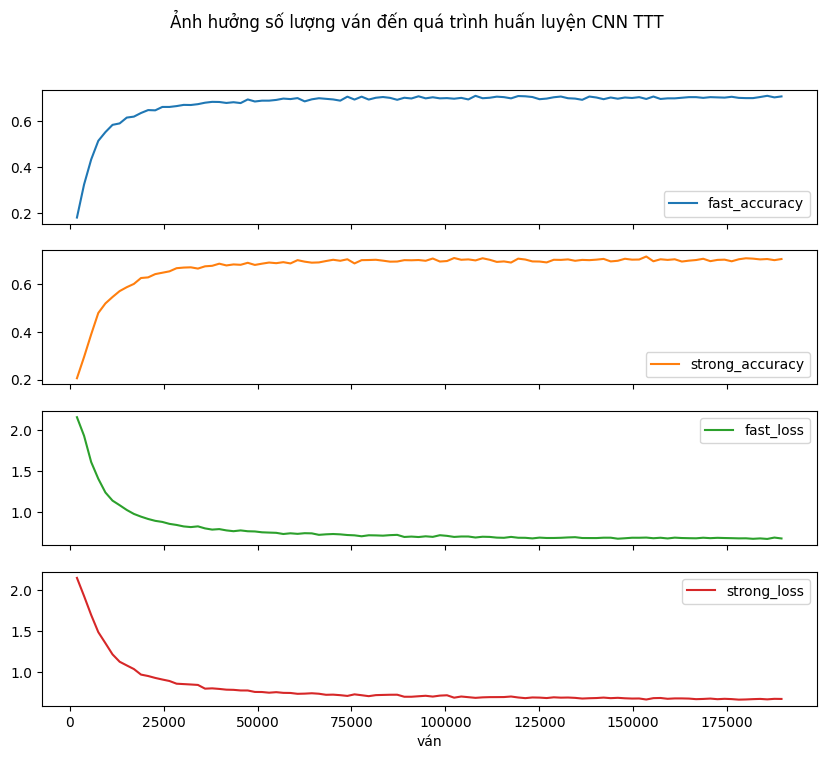

In [21]:
pd.DataFrame({"ván": np.arange(1, len(fast_ttt_history.history["loss"]) + 1) * len(X), "fast_accuracy": fast_ttt_history.history["accuracy"], "strong_accuracy": strong_ttt_history.history["accuracy"], "fast_loss": fast_ttt_history.history["loss"], "strong_loss": strong_ttt_history.history["loss"]}).set_index("ván").plot(subplots=True, figsize=(10, 8), title="Ảnh hưởng số lượng ván đến quá trình huấn luyện CNN TTT")

### MCTS

In [14]:
import pickle
from tqdm.auto import tqdm
from utils.ttt_simple_env import ttt
from utils.ch08util import mcts


def play_ttt_mcts_game():
    env = ttt()
    env.reset()
    mcts_first = np.random.rand() < 0.5
    while True:
        action = mcts(env, num_rollouts=1000) if mcts_first else env.sample()
        state, reward, done, info = env.step(action)
        if done:
            return reward if mcts_first else -reward
        action = env.sample() if mcts_first else mcts(env, num_rollouts=1000)
        state, reward, done, info = env.step(action)
        if done:
            return reward if mcts_first else -reward


ttt_mcts_results = []
for game_number in tqdm(range(100), desc="TTT MCTS", unit="ván"):
    ttt_mcts_results.append(play_ttt_mcts_game())
    if (game_number + 1) % 10 == 0:
        with open("files/checkpoints/ttt_mcts_checkpoint.p", "wb") as fp:
            pickle.dump(ttt_mcts_results, fp)

with open("files/checkpoints/ttt_mcts_results.p", "wb") as fp:
    pickle.dump(ttt_mcts_results, fp)

print("TTT MCTS thắng:", ttt_mcts_results.count(1))
print("TTT MCTS hòa:", ttt_mcts_results.count(0))
print("TTT MCTS thua:", ttt_mcts_results.count(-1))

TTT MCTS: 100%|██████████| 100/100 [00:25<00:00,  3.88ván/s]

TTT MCTS thắng: 91
TTT MCTS hòa: 6
TTT MCTS thua: 3


### Mix MCTS + NN

In [23]:
import pickle
from tqdm.auto import tqdm
from tensorflow.keras.models import load_model
from utils.ttt_simple_env import ttt
from utils.ch08util import expand, simulate, backpropagate


def mix_select_ttt(env, priors, counts, wins, losses, temperature=0):
    scores = {}
    total = max(sum(counts.values()), 1)
    for move in env.validinputs:
        if counts[move] == 0:
            return move
        value = (wins.get(move, 0) - losses.get(move, 0)) / counts[move]
        exploration = temperature * np.sqrt(np.log(total) / counts[move])
        scores[move] = value + exploration + priors[move]
    return max(scores, key=scores.get)


def mix_mcts_ttt(env, model, num_rollouts=200, temperature=1.4):
    if len(env.validinputs) == 1:
        return env.validinputs[0]
    board = env.state.reshape(1, 3, 3, 1)
    if env.turn == "O":
        board = -board
    probabilities = np.asarray(model(board, training=False)).reshape(-1)
    priors = {move: float(probabilities[move - 1]) for move in env.validinputs}
    counts = {move: 0 for move in env.validinputs}
    wins = {move: 0 for move in env.validinputs}
    losses = {move: 0 for move in env.validinputs}
    for _ in range(num_rollouts):
        move = mix_select_ttt(env, priors, counts, wins, losses, temperature)
        env_copy, done, reward = expand(env, move)
        reward = simulate(env_copy, done, reward)
        counts, wins, losses = backpropagate(env, move, reward, counts, wins, losses)
    return max(counts, key=counts.get)


strong_ttt_model = load_model("files/strong_ttt.h5")
ttt_policy_mcts_results = []
for game_number in tqdm(range(100), desc="TTT Policy MCTS", unit="ván"):
    env = ttt()
    env.reset()
    policy_first = np.random.rand() < 0.5
    while True:
        action = mix_mcts_ttt(env, strong_ttt_model) if policy_first else env.sample()
        state, reward, done, info = env.step(action)
        if done:
            ttt_policy_mcts_results.append(reward if policy_first else -reward)
            break
        action = env.sample() if policy_first else mix_mcts_ttt(env, strong_ttt_model)
        state, reward, done, info = env.step(action)
        if done:
            ttt_policy_mcts_results.append(reward if policy_first else -reward)
            break
    if (game_number + 1) % 10 == 0:
        with open("files/checkpoints/ttt_policy_mcts_checkpoint.p", "wb") as fp:
            pickle.dump(ttt_policy_mcts_results, fp)

with open("files/checkpoints/ttt_policy_mcts_results.p", "wb") as fp:
    pickle.dump(ttt_policy_mcts_results, fp)

print("TTT Policy MCTS thắng:", ttt_policy_mcts_results.count(1))
print("TTT Policy MCTS hòa:", ttt_policy_mcts_results.count(0))
print("TTT Policy MCTS thua:", ttt_policy_mcts_results.count(-1))

TTT Policy MCTS: 100%|██████████| 100/100 [00:07<00:00, 13.01ván/s]

TTT Policy MCTS thắng: 97
TTT Policy MCTS hòa: 2
TTT Policy MCTS thua: 1


In [24]:
import pickle
from tqdm.auto import tqdm
from tensorflow.keras.models import load_model
from utils.ttt_simple_env import ttt
from utils.ch08util import mcts


strong_ttt_model = load_model("files/strong_ttt.h5")
ttt_uct_vs_mix_results = []

for game_number in tqdm(range(100), desc="UCT MCTS vs Mix MCTS", unit="ván"):
    env = ttt()
    env.reset()
    uct_first = game_number % 2 == 0

    while True:
        if uct_first:
            action = mcts(env, num_rollouts=1000)
        else:
            action = mix_mcts_ttt(env, strong_ttt_model, num_rollouts=200)
        state, reward, done, info = env.step(action)
        if done:
            ttt_uct_vs_mix_results.append(reward if uct_first else -reward)
            break

        if uct_first:
            action = mix_mcts_ttt(env, strong_ttt_model, num_rollouts=200)
        else:
            action = mcts(env, num_rollouts=1000)
        state, reward, done, info = env.step(action)
        if done:
            ttt_uct_vs_mix_results.append(-reward if uct_first else reward)
            break

    if (game_number + 1) % 10 == 0:
        with open("files/checkpoints/ttt_uct_vs_mix_checkpoint.p", "wb") as fp:
            pickle.dump(ttt_uct_vs_mix_results, fp)

with open("files/checkpoints/ttt_uct_vs_mix_results.p", "wb") as fp:
    pickle.dump(ttt_uct_vs_mix_results, fp)

uct_wins = ttt_uct_vs_mix_results.count(1)
mix_wins = ttt_uct_vs_mix_results.count(-1)
draws = ttt_uct_vs_mix_results.count(0)

print(f"UCT MCTS wins: {uct_wins}")
print(f"Mix MCTS wins: {mix_wins}")
print(f"Draws: {draws}")

UCT MCTS vs Mix MCTS: 100%|██████████| 100/100 [00:38<00:00,  2.63ván/s]

UCT MCTS wins: 0
Mix MCTS wins: 24
Draws: 76


### AlphaGO Implement

### Huấn luyện mỗi checkpoint và quan sát

Chạy huấn luyện 10000 lần cho mỗi Agent ngoại trừ Rule-based AI

In [ ]:
ttt_nn = train_policy("ttt", episodes=TRAIN_EPISODES["ttt"], checkpoint=CHECKPOINTS / "ttt_policy.npz")
print("Tic-Tac-Toe policy đã huấn luyện:", CHECKPOINTS / "ttt_policy.npz")

Lưu checkpoint

In [ ]:
ttt_nn.save(CHECKPOINTS / "ttt_policy.npz")
print("Đã lưu checkpoint Tic-Tac-Toe")

Chơi với player random và xem kết quả

In [ ]:
ttt_results = evaluate_agent("ttt", {
    "Rule-based": ttt_rule_agent,
    "Neural Network": ttt_nn_agent,
    "MCTS": ttt_mcts_agent,
    "MCTS + NN": ttt_mcts_nn_agent,
    "AlphaGo": ttt_alphago_agent,
})
ttt_results
plot_results(ttt_results, "Tic-Tac-Toe: đánh giá với random player")

## Connect 4

### Áp dụng rule-based AI

In [ ]:
conn_rule_agent = lambda env: rule_agent(env, "conn")
conn_rule_agent

### Neural Network

In [ ]:
conn_nn = load_or_train_policy("conn", "conn_policy.npz")
conn_nn_agent = lambda env: policy_action(conn_nn, env, "conn")
conn_nn_agent

### MCTS

In [ ]:
conn_mcts_agent = lambda env: mcts(env, num_rollouts=MCTS_ROLLOUTS["conn"])
conn_mcts_agent

### MCTS + NN

In [ ]:
conn_mcts_nn_agent = lambda env: mcts_nn_agent(env, "conn", conn_nn)
conn_mcts_nn_agent

### AlphaGO Implement

In [ ]:
conn_alphago_agent = lambda env: alphago_agent(env, "conn", conn_nn)
conn_alphago_agent

### Huấn luyện mỗi checkpoint và quan sát

Chạy huấn luyện 10000 lần cho mỗi Agent ngoại trừ Rule-based AI

In [ ]:
conn_nn = train_policy("conn", episodes=TRAIN_EPISODES["conn"], checkpoint=CHECKPOINTS / "conn_policy.npz")
print("Connect Four policy đã huấn luyện:", CHECKPOINTS / "conn_policy.npz")

Lưu checkpoint

In [ ]:
conn_nn.save(CHECKPOINTS / "conn_policy.npz")
print("Đã lưu checkpoint Connect Four")

Chơi với player random và xem kết quả

In [ ]:
conn_results = evaluate_agent("conn", {
    "Rule-based": lambda env: rule_agent(env, "conn"),
    "Neural Network": lambda env: policy_action(conn_nn, env, "conn"),
    "MCTS": conn_mcts_agent,
    "MCTS + NN": conn_mcts_nn_agent,
    "AlphaGo": conn_alphago_agent,
})
conn_results
plot_results(conn_results, "Connect Four: đánh giá với random player")